# 37009 Risk Management — Assessment Task 3 (AT3) 
**Case Study & Presentation**

> **Name:** Clint Sellen
> **Student ID:** 12685400
> **Date:** 2025-11-19

---


In [2]:
# Imports
from IPython.display import display, Markdown, Math
from enum import Enum
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context="notebook", style="whitegrid")

from dataclasses import dataclass
from typing import Tuple, Dict, Callable, Union, List, Optional
from pathlib import Path

from scipy import stats, fft

# Plotting parameters
figure_size = (12, 8)

## Question 1 — Risk Allocation
**Data:** `AT3RiskAllocationData.csv`

**Tasks:**
1) Mean vector & unbiased covariance of asset & portfolio losses; discuss correlations.
2) 95% $VaR$ & $ES$ (empirical) of portfolio.
3) Euler allocation under $VaR$ (check full allocation).
4) Euler allocation under $ES$ (then adjust to match $ES$).
5) $RORAC$ for portfolio and per asset (using $VaR-based$ allocation).
6) Approximate $\Delta VaR$ when adding one extra unit of Asset 4.

In [48]:
# Implementation of RiskAllocation class

class HISTORICAL_WEIGHT_TYPE(Enum):
    EQUAL = "equal"

class RiskAllocation:
    """
    A class for performing risk allocation calculations.
    """
    def __init__(self, loss_scenarios: pd.DataFrame, confidence_level: float = 0.95):
        self.loss_scenarios = loss_scenarios
        self.assets = loss_scenarios.columns
        self.alpha = confidence_level
        
        # Initialise output DataFrame
        self.df = pd.DataFrame(index=['mean'], columns=loss_scenarios.columns)
        self.covariance_matrix = None
        self.correlation_matrix = None
    
    def plot_loss_scenarios(self):
        """
        Plot the loss scenarios.
        """
        loss_scenarios_melted = self.loss_scenarios.reset_index().melt(
            id_vars='index', 
            value_vars=self.loss_scenarios.columns,
            var_name='Asset', 
            value_name='Loss'
        )
        plt.figure(figsize=figure_size)
        sns.lineplot(
            data=loss_scenarios_melted, 
            x='index', 
            y='Loss', 
            hue='Asset'
        )
        plt.title('Loss Scenarios by Asset')
        plt.xlabel('Scenario')
        plt.ylabel('Loss')
        plt.show()
    
    def plot_loss_scenarios_histogram(self):
        """
        Plot the loss scenarios as a histogram.
        """
        for asset_i in self.assets:
            VaR_95 = np.quantile(self.loss_scenarios[asset_i], self.alpha, method='linear')
            plt.figure(figsize=figure_size)
            sns.histplot(
                data=self.loss_scenarios[asset_i], 
                bins=100, 
                kde=False,
                stat='density'
            )
            # Add vertical line at the quantile
            plt.axvline(x=VaR_95, color='red', linestyle='--', linewidth=1, label=f'95% VaR: {VaR_95:.2f}')
            plt.title(f'Histogram of {asset_i} Losses with {self.alpha*100}% VaR')
            plt.xlabel('Loss')
            plt.ylabel('Density')
            plt.legend()
            plt.show()
    
    def calculate_mean_vector(self):
        """
        Calculates the mean vector from the loss scenarios data.

        This method computes the mean of each asset's losses using the pandas DataFrame.mean() function
        and stores the results in the 'mean' row of self.df.

        Parameters
        ----------
        None

        Returns
        -------
        pandas.DataFrame
            The updated self.df containing the calculated mean values.
        """
        display(Markdown(f"#### Mean Vector"))
        self.df.loc['mean'] = self.loss_scenarios.mean()
        return self.df
    
    def calculate_covariance_matrix(self, display_output: bool = False, plot: bool = False):
        """
        Calculates the unbiased covariance matrix from the loss scenarios data.

        This method uses the pandas DataFrame.cov() function with ddof=1 to compute the covariance.
        Optionally displays the matrix in the notebook output and/or plots a heatmap visualization.

        Parameters
        ----------
        display_output : bool, optional
            If True, displays the covariance matrix using IPython.display. Default is False.
        plot : bool, optional
            If True, generates and shows a seaborn heatmap of the covariance matrix. Default is False.

        Returns
        -------
        None
            Updates self.covariance_matrix with the computed values but does not return anything.
        """
        self.covariance_matrix = self.loss_scenarios.cov(ddof=1)
        if plot:
            # Plot the Covariance heatmap
            plt.figure(figsize=figure_size)
            sns.heatmap(self.covariance_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
            plt.title('(Unbiased) Covariance Heatmap')
            plt.show()
        if display_output:
            display(Markdown(f"#### Covariance Matrix"))
            display(self.covariance_matrix)


    def calculate_correlation_matrix(self, display_output: bool = False, plot: bool = False):
        """
        Calculates the Pearson correlation matrix from the loss scenarios data.

        This method uses the pandas DataFrame.corr() function with method='pearson' to compute the correlations.
        Optionally displays the matrix in the notebook output and/or plots a heatmap visualization.

        Parameters
        ----------
        display_output : bool, optional
            If True, displays the correlation matrix using IPython.display. Default is False.
        plot : bool, optional
            If True, generates and shows a seaborn heatmap of the correlation matrix. Default is False.

        Returns
        -------
        None
            Updates self.correlation_matrix with the computed values but does not return anything.
        """
        self.correlation_matrix = self.loss_scenarios.corr(method='pearson')
        if plot:
            # Plot the Correlation heatmap
            plt.figure(figsize=(10, 8))
            sns.heatmap(self.correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
            plt.title('Correlation Heatmap')
            plt.show()
        if display_output:
            display(Markdown(f"#### Correlation Matrix"))
            display(self.correlation_matrix)
    
    def VaR_ES_empirical(
        self,
        asset: str,
        hs_weight_type: HISTORICAL_WEIGHT_TYPE = HISTORICAL_WEIGHT_TYPE.EQUAL, 
        confidence_level: Optional[float] = None, 
        # age_weight_decay: float = 0.94,
        display_output: bool = False):
        """
        Calculates VaR and ES using empirical methods.
        Reference: University of Technology Sydney. (2025). Market Risk Analysis [Workshop]. Faculty of Science, Master of Quantitative Finance, University of Technology Sydney.

        Parameters:
            loss_scenarios (Union[np.ndarray, List[float]]): Loss scenarios.
            hs_weight_type (HISTORICAL_WEIGHT_TYPE): Weighting type for historical simulation.
            confidence_level (Optional[float], optional): Confidence level. Defaults to None.
            age_weight_decay (float, optional): Decay factor for age weighting. Defaults to 0.94.
            display_output (bool, optional): Whether to display results. Defaults to False.

        Returns:
            np.ndarray: Array with VaR and ES.
        """
        VaR = None
        ES = None
        alpha = confidence_level if confidence_level is not None else self.alpha
        loss_scenarios = self.loss_scenarios[asset]
        
        if hs_weight_type == HISTORICAL_WEIGHT_TYPE.EQUAL:
            VaR = np.quantile(loss_scenarios, alpha)
            ES = np.maximum(loss_scenarios - VaR, 0).mean() / (1 - alpha) + VaR
        
        if display_output:
            display(Markdown(f"### {asset} $VaR_{{{self.alpha}}}$ & $ES_{{{self.alpha}}}$ (empirical)"))
            display(Markdown(f"#### &emsp; - VaR: {VaR:.4f}<br /> &emsp; - ES: {ES:.4f}"))
        
        self.portfolio_VaR = VaR
        self.portfolio_ES = ES
        # Return output
        return np.array([VaR, ES])
    
    def Euler_allocation_VaR_approximation(
        self,
        portfolio_VaR: float):
        """
        Calculates the approximate Euler allocation for Value at Risk (VaR) using a linear approximation.

        This method computes the allocation contribution (AC) for each asset based on the mean losses,
        covariance with the portfolio, and the provided portfolio VaR. It uses the formula:
        AC_i = μ_i + (Cov(L_i, L) / Var(L)) * (VaR - μ_L)
        Results are stored in self.df under the row "AC (Euler) VaR {alpha} (approx)".
        Finally, it verifies if the sum of allocations equals the portfolio VaR and displays the result.

        Parameters
        ----------
        portfolio_VaR : float
            The pre-calculated Value at Risk for the entire portfolio.

        Returns
        -------
        None
            Updates self.df with the allocation values and displays a verification message.
        """
        if self.covariance_matrix is None:
            self.calculate_covariance_matrix(plot=False, display_output=False)
        
        for asset in self.assets:
            if asset == 'Portfolio':
                continue
            mu_i = self.df.loc['mean', asset]
            Cov_Li_L = self.covariance_matrix.loc[asset, 'Portfolio']
            var_L = self.covariance_matrix.loc['Portfolio', 'Portfolio']
            mu_L = self.df.loc['mean', 'Portfolio']
            AC_i = mu_i + Cov_Li_L / var_L * (portfolio_VaR - mu_L)
            self.df.loc[f"AC (Euler) VaR {self.alpha} (approx)", asset] = AC_i

        ac_portfolio = self.df[self.df.columns[1:]].loc[f"AC (Euler) VaR {self.alpha} (approx)"].sum()
        self.df.loc[f"AC (Euler) VaR {self.alpha} (approx)", 'Portfolio'] = ac_portfolio
        
        if np.isclose(ac_portfolio, portfolio_VaR):
            display(Markdown(f"#### Euler allocation satisfies full allocation property, $\\text{{AC}}^{{VaR_{{ {self.alpha} }} }}_{{portfolio}}: {ac_portfolio:.4f} = \\text{{VaR}}_{{ {self.alpha} }}(L): {portfolio_VaR:.4f}$"))
        else:
            display(Markdown(f"#### Euler allocation does not satisfy full allocation property, $\\text{{AC}}^{{VaR_{{ {self.alpha} }} }}_{{portfolio}}: {ac_portfolio:.4f} \\neq \\text{{VaR}}_{{ {self.alpha} }}(L): {portfolio_VaR:.4f}$"))


    def Euler_allocation_ES_approximation(self, portfolio_VaR: float, portfolio_ES: float):
        """
        Calculates the approximate Euler allocation for Expected Shortfall (ES) using tail loss averages.

        This method computes the allocation capital (AC) for each asset by averaging the losses
        in scenarios where the portfolio loss exceeds the given portfolio VaR, scaled by the tail probability.
        Results are stored in self.df under the row "AC (Euler) ES {alpha}".
        If the sum of allocations does not equal the portfolio ES, it displays a message, applies a scaling
        adjustment to satisfy the full allocation property, and stores the adjusted values in
        "AC (Euler) ES {alpha} (adjusted)". It then verifies and displays the result of the adjustment.

        Note: The calculation uses an approximation where the tail average is computed as
        sum(tail_losses) / total_scenarios / (1 - alpha), which assumes the number of tail scenarios
        is exactly total_scenarios * (1 - alpha).

        Parameters
        ----------
        portfolio_VaR : float
            The pre-calculated Value at Risk for the portfolio, used to identify tail scenarios.
        portfolio_ES : float
            The pre-calculated Expected Shortfall for the portfolio, used for verification and adjustment.

        Returns
        -------
        None
            Updates self.df with allocation values and displays verification messages.
        """
        if self.covariance_matrix is None:
            self.calculate_covariance_matrix(plot=False, display_output=False)
        
        era_ES = list[float]()
        for asset_i in self.assets:
            if asset_i == 'Portfolio':
                continue
            losses_i = list[float]()
            for index, row in self.loss_scenarios[self.loss_scenarios['Portfolio'] >= portfolio_VaR].iterrows():
                loss = self.loss_scenarios.loc[index, asset_i]
                losses_i.append(loss)
            ES_i = (np.sum(losses_i) / len(self.loss_scenarios)) / (1 - self.alpha)
            self.df.loc[f'AC (Euler) ES {self.alpha}', asset_i] = ES_i
            era_ES.append(ES_i)

        self.df.loc[f'AC (Euler) ES {self.alpha}', 'Portfolio'] = self.df[self.df.columns[1:]].loc[f'AC (Euler) ES {self.alpha}'].sum()
        ac_portfolio = self.df.loc[f"AC (Euler) ES {self.alpha}", 'Portfolio']

        if not np.isclose(ac_portfolio, portfolio_ES): 
            display(Markdown(f"#### Expected shortfall portfolio allocation does not meet full allocation principle, $\\text{{AC}}^{{ES_{{ {self.alpha} }} }}_{{portfolio}}: {ac_portfolio:.4f} \\neq \\text{{ES}}_{{ {self.alpha} }}(L): {portfolio_ES:.4f}$"))
            for asset_i in self.assets[1:]:
                self.df.loc[f"AC (Euler) ES {self.alpha} (adjusted)", asset_i] = portfolio_ES * self.df.loc[f"AC (Euler) ES {self.alpha}", asset_i] / self.df.loc[f"AC (Euler) ES {self.alpha}", 'Portfolio']
            
            self.df.loc[f'AC (Euler) ES {self.alpha} (adjusted)', 'Portfolio'] = self.df[self.df.columns[1:]].loc[f'AC (Euler) ES {self.alpha} (adjusted)'].sum()
            ac_portfolio = self.df.loc[f"AC (Euler) ES {self.alpha} (adjusted)", 'Portfolio']
            
            if np.isclose(ac_portfolio, portfolio_ES):
                display(Markdown(f"#### Adjusted Expected shortfall portfolio allocation satisfies full allocation principle, $\\text{{AC}}^{{ES_{{ {self.alpha} }} }}_{{portfolio}}: {ac_portfolio:.4f} = \\text{{ES}}_{{ {self.alpha} }}(L): {portfolio_ES:.4f}$"))
            else:
                display(Markdown(f"#### Adjusted Expected shortfall portfolio allocation does not meet full allocation principle, $\\text{{AC}}^{{ES_{{ {self.alpha} }} }}_{{portfolio}}: {ac_portfolio:.4f} \\neq \\text{{ES}}_{{ {self.alpha} }}(L): {portfolio_ES:.4f}$"))

    def RORAC_VaR(self):
        """
        Calculates the Return on Risk-Adjusted Capital (RORAC) based on VaR Euler allocations for each asset and the portfolio.

        This method computes RORAC as the expected return (negative mean loss) divided by the allocated capital (AC) from VaR.
        If the allocated capital is negative (indicating a hedge or diversification benefit), RORAC is set to NaN.
        Results are stored in self.df under the row "RORAC VaR {alpha}".
        It then displays Markdown messages for each asset and the portfolio, highlighting hedges or showing the RORAC values.

        Parameters
        ----------
        None

        Returns
        -------
        None
            Updates self.df with RORAC values and displays interpretive messages.
        """
        for asset_i in self.assets:
            E_L_i = -self.df.loc['mean', asset_i]
            AC_L_i = self.df.loc[f"AC (Euler) VaR {self.alpha} (approx)", asset_i]
            RORAC_L_i = E_L_i / AC_L_i
            # If the asset is a hedge, risk capital is negative and return on risk-adjusted capital 
            # is undefined because the position alleviates capital allocation
            if AC_L_i < 0:
                RORAC_L_i = np.nan
            self.df.loc[f"RORAC VaR {self.alpha}", asset_i] = RORAC_L_i
        for i in self.df.columns:
            if np.isnan(self.df.loc[f'RORAC VaR {self.alpha}', i]):
                if i == 'Portfolio':
                    display(Markdown(f"#### - $RORAC(L)$ = {self.df.loc[f'RORAC VaR {self.alpha}', i]:.4f}"))
                else:
                    display(Markdown(f"#### - $AC_{{ {i} }}^{{VaR_{{ {self.alpha} }} }} < 0 \\rightarrow$ indicates that the position acts as a **hedge** or provides **diversification benefit**."))
            else:
                if i == 'Portfolio':
                    display(Markdown(f"#### - $RORAC(L)$ = {self.df.loc[f'RORAC VaR {self.alpha}', i]:.4f}"))
                else:
                    display(Markdown(f"#### - $RORAC(L_{{ {i} }} | L)$ = {self.df.loc[f'RORAC VaR {self.alpha}', i]:.4f}"))

    
    def RORAC_ES(self):
        """
        Calculates the Return on Risk-Adjusted Capital (RORAC) based on Expected Shortfall (ES) Euler allocations for each asset and the portfolio.

        This method computes RORAC as the expected return (negative mean loss) divided by the allocated capital (AC) from ES.
        If the allocated capital is negative (indicating a hedge or diversification benefit), RORAC is set to NaN.
        Results are stored in self.df under the row "RORAC ES {alpha}".

        Parameters
        ----------
        None

        Returns
        -------
        None
            Updates self.df with RORAC values.
        """
        for asset_i in self.assets:
            E_L_i = -self.df.loc['mean', asset_i]
            AC_L_i = self.df.loc[f"AC (Euler) ES {self.alpha}", asset_i]
            RORAC_L_i = E_L_i / AC_L_i
            # If the asset is a hedge, risk capital is negative and return on risk-adjusted capital 
            # is undefined because the position alleviates capital allocation
            if AC_L_i < 0:
                RORAC_L_i = np.nan
            self.df.loc[f"RORAC ES {self.alpha}", asset_i] = RORAC_L_i
    
    def run(self):
        self.calculate_mean_vector()
        self.calculate_covariance_matrix(plot=True, display_output=True)
        self.calculate_correlation_matrix(plot=True, display_output=True)
        self.VaR_ES_empirical(asset='Portfolio', hs_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL, confidence_level=None, display_output=True)
        self.Euler_allocation_VaR_approximation(portfolio_VaR=self.portfolio_VaR)
        self.Euler_allocation_ES_approximation(portfolio_VaR=self.portfolio_VaR, portfolio_ES=self.portfolio_ES)
        self.RORAC_VaR()
        self.RORAC_ES()


In [49]:
# Import data and validate
path = Path("AT3RiskAllocationData.csv")
loss_scenarios = pd.read_csv(path)
display(loss_scenarios.head())

loss_portfolio = loss_scenarios['Portfolio'].to_numpy()
total_loss_portfolio = loss_portfolio.sum()
print(f"Total loss portfolio: ${total_loss_portfolio:.2f}")

loss_assets = loss_scenarios[['Asset1', 'Asset2', 'Asset3', 'Asset4']].to_numpy()
total_loss_assets = loss_assets.sum(axis=1).sum()
print(f"Total loss assets: ${total_loss_assets:.2f}")

assert np.allclose(total_loss_portfolio, total_loss_assets)


,Portfolio,Asset1,Asset2,Asset3,Asset4
0,8.7730,3.9543,-15.9787,-5.3125,26.1100
1,-7.2013,8.4499,1.4312,-16.5658,-0.5166
2,11.9202,-4.3256,-8.8200,9.1504,15.9154
3,11.7202,-13.0794,-2.5536,21.1534,6.1997
4,17.7754,-29.0296,-8.7228,39.7568,15.7710


Total loss portfolio: $11278.87
Total loss assets: $11278.87


In [50]:
# Constants
CONFIDENCE_LEVEL = 0.95

# Initialise risk allocation object
risk_allocation = RiskAllocation(loss_scenarios = loss_scenarios, confidence_level = CONFIDENCE_LEVEL)
# risk_allocation.plot_loss_scenarios()


## Task 1.1
- Calculate the mean vector and the (unbiased) covariance matrix estimate of the loss scenarios.
- What can be said about the correlation of the portfolio level loss with the asset-level loss?

#### Mean Vector

,Portfolio,Asset1,Asset2,Asset3,Asset4
mean,1.752737,-2.017917,0.183078,2.749561,0.838016


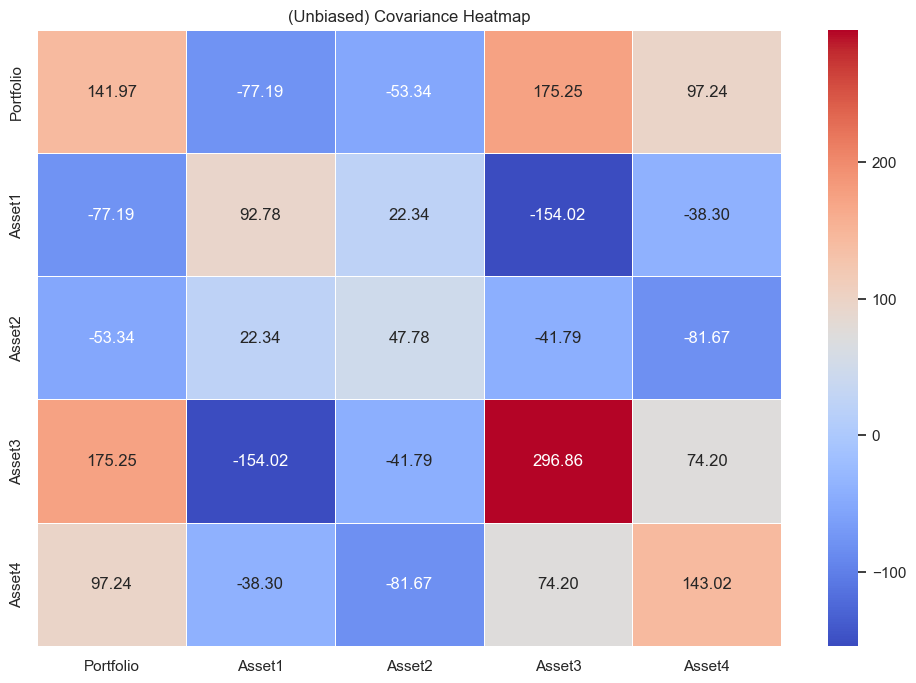

In [51]:
mean_vector = risk_allocation.calculate_mean_vector()
display(mean_vector)

risk_allocation.calculate_covariance_matrix(plot=True, display_output=False)

### Interpretation of Portfolio–Asset Covariances

| Asset | Cov(Portfolio, Asset) | Interpretation |
|--------|------------------------|----------------|
| Asset 1 | −77.19 | Moves opposite to portfolio losses → **hedging / diversification**. |
| Asset 2 | −53.34 | Slight hedge, reduces overall portfolio risk. |
| Asset 3 | +175.25 | Strongly co-moves with portfolio losses → **major risk driver**. |
| Asset 4 | +97.24 | Positively correlated, contributes to total risk but less than Asset 3. |

**Conclusion:**  
Assets 3 and 4 are positively correlated with portfolio losses and therefore **increase** portfolio risk.  
Assets 1 and 2 have negative covariance with portfolio losses and thus **reduce** risk through diversification.

Overall, the covariance structure shows that the portfolio’s total loss
is primarily driven by Assets 3 and 4, while Assets 1 and 2 act as partial hedges.

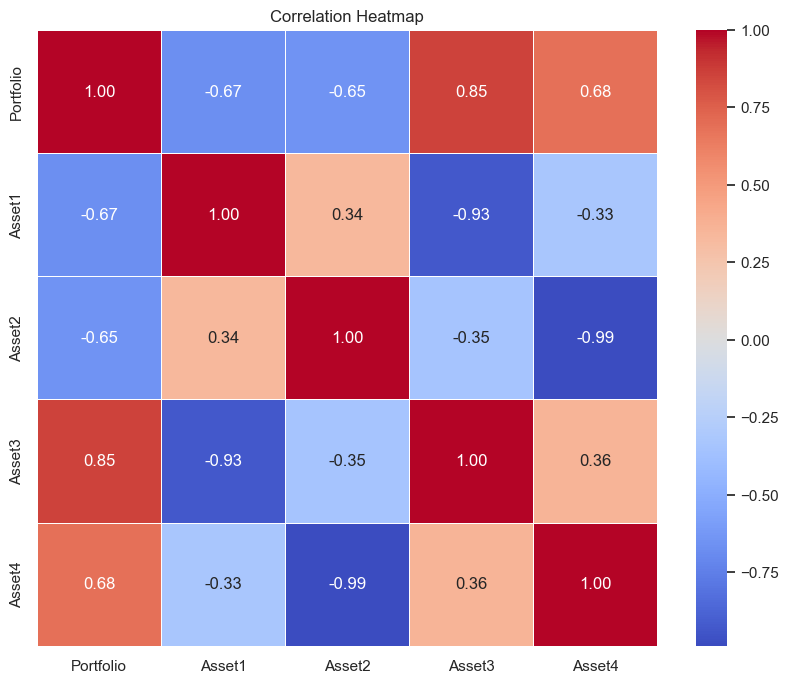

In [52]:
risk_allocation.calculate_correlation_matrix(plot=True)

## Task 1.2
- Using the empirical distribution of portfolio-level losses (with equal weights/probabilities), calculate the 95% VaR and ES of the portfolio.

In [53]:
portfolio_VaR, portfolio_ES = risk_allocation.VaR_ES_empirical(
    asset='Portfolio',
    hs_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
    display_output=True)

### Portfolio $VaR_{0.95}$ & $ES_{0.95}$ (empirical)

#### &emsp; - VaR: 14.8356<br /> &emsp; - ES: 18.0861

## Task 1.3
- Calculate the Euler risk capital allocation for each asset using VaR as the risk measure. Does this risk capital allocation satisfy the full allocation property?

Linear approximation of $ AC_i^{\text{VaR}} $:

$$
AC_i^{\text{VaR}} \approx 
\mu_i 
+ 
\frac{\operatorname{Cov}(L_i, L)}{\operatorname{Var}(L)}
\left( \operatorname{VaR}_{\alpha}(L) - \mathbb{E}[L] \right).
$$

In [54]:
risk_allocation.Euler_allocation_VaR_approximation(portfolio_VaR=portfolio_VaR)

#### Euler allocation satisfies full allocation property, $\text{AC}^{VaR_{ 0.95 } }_{portfolio}: 14.8356 = \text{VaR}_{ 0.95 }(L): 14.8356$

In [79]:
display(risk_allocation.df.loc['AC (Euler) VaR 0.95 (approx)'])

Portfolio    14.835579
Asset1       -9.131581
Asset2       -4.732331
Asset3       18.899897
Asset4        9.799593
Name: AC (Euler) VaR 0.95 (approx), dtype: object

## Task 1.4
- Calculate the Euler risk capital allocation for each asset using ES as the risk measure.
- Due to the approximations used, the allocation may not satisfy the full allocation property, so adjust the
risk capital allocation so they add up to the portfolio ES.

$$
\begin{align*}
\text{AC}^{\text{ES}}_{i} =

\frac{\partial r_{\mathrm{ES},\alpha}(\lambda)}{\partial \lambda_i}
&= \frac{1}{1-\alpha} 
\int_{\mathrm{VaR}_\alpha(\mathcal{L}(\lambda))}^{\infty} 
\mathbb{E}[L_i \mid \mathcal{L}(\lambda) = w] \, f_{\mathcal{L}(\lambda)}(w)\, dw \\

&= \frac{1}{1-\alpha}
\int_{-\infty}^{\infty} 
\mathbb{E}\!\left[L_i \mathbf{1}_{\{w \ge \mathrm{VaR}_\alpha(\mathcal{L}(\lambda))\}} 
\mid \mathcal{L}(\lambda)=w \right] 
f_{\mathcal{L}(\lambda)}(w)\, dw \\

&= \frac{1}{1-\alpha} 
\mathbb{E}\!\left[
\mathbb{E}\!\left[L_i \mathbf{1}_{\{\mathcal{L}(\lambda)\ge 
\mathrm{VaR}_\alpha(\mathcal{L}(\lambda))\}} 
\mid \mathcal{L}(\lambda)\right] \right] \\

&= \frac{1}{1-\alpha} 
\mathbb{E}\!\left[
L_i \mathbf{1}_{\{\mathcal{L}(\lambda)\ge 
\mathrm{VaR}_\alpha(\mathcal{L}(\lambda))\}}
\right] \\

&= 
\mathbb{E}\!\left[
L_i \mid 
\mathcal{L}(\lambda) \ge 
\mathrm{VaR}_\alpha(\mathcal{L}(\lambda))
\right].
\end{align*}
$$

In [55]:
risk_allocation.Euler_allocation_ES_approximation(portfolio_VaR=portfolio_VaR, portfolio_ES=portfolio_ES)

#### Expected shortfall portfolio allocation does not meet full allocation principle, $\text{AC}^{ES_{ 0.95 } }_{portfolio}: 18.0977 \neq \text{ES}_{ 0.95 }(L): 18.0861$

#### Adjusted Expected shortfall portfolio allocation satisfies full allocation principle, $\text{AC}^{ES_{ 0.95 } }_{portfolio}: 18.0861 = \text{ES}_{ 0.95 }(L): 18.0861$

In [77]:
display(risk_allocation.df.loc['AC (Euler) ES 0.95 (adjusted)'])

Portfolio    18.086145
Asset1      -21.188587
Asset2      -14.479131
Asset3       30.240917
Asset4       23.512945
Name: AC (Euler) ES 0.95 (adjusted), dtype: object

## Task 1.5
- Determine the return on risk-adjusted capital for the entire portfolio and for each asset using the
Euler risk allocation under the VaR.

$$
RORAC(L) := \dfrac{\mathbb{E}[−L]}{\psi(L)}, \,  RORAC(L_{i}|L) := \dfrac{\mathbb{E}[−L_{i}]}{AC_{i}^{\psi}}
$$

In [56]:
risk_allocation.RORAC_VaR()

#### - $RORAC(L)$ = -0.1181

#### - $AC_{ Asset1 }^{VaR_{ 0.95 } } < 0 \rightarrow$ indicates that the position acts as a **hedge** or provides **diversification benefit**.

#### - $AC_{ Asset2 }^{VaR_{ 0.95 } } < 0 \rightarrow$ indicates that the position acts as a **hedge** or provides **diversification benefit**.

#### - $RORAC(L_{ Asset3 } | L)$ = -0.1455

#### - $RORAC(L_{ Asset4 } | L)$ = -0.0855

## Task 1.6
- By how much (approximately) is the $VaR$ expected to change if we hold one additional unit of Asset 4, keeping the position in the other assets the same?


In [57]:
_loss_scenarios = loss_scenarios.copy(deep=True)
_loss_scenarios['Portfolio'] = _loss_scenarios['Asset1'] + _loss_scenarios['Asset2'] + _loss_scenarios['Asset3'] + _loss_scenarios['Asset4'] * 2

_risk_allocation = RiskAllocation(loss_scenarios = _loss_scenarios, confidence_level = CONFIDENCE_LEVEL)
# _risk_allocation.run()

_portfolio_VaR, _portfolio_ES = _risk_allocation.VaR_ES_empirical(
    asset='Portfolio',
    hs_weight_type=HISTORICAL_WEIGHT_TYPE.EQUAL,
    display_output=True)



### Portfolio $VaR_{0.95}$ & $ES_{0.95}$ (empirical)

#### &emsp; - VaR: 31.6428<br /> &emsp; - ES: 44.0484

In [60]:
display(Markdown(f"#### Increasing Asset 4 by 1 unit while keeping the position in the other assets the same increases $VaR_{{ {CONFIDENCE_LEVEL} }}(L)$ from ${portfolio_VaR:.4f}$ to ${_portfolio_VaR:.4f}$, a difference of ${_portfolio_VaR - portfolio_VaR:.4f}$.")) 

#### Increasing Asset 4 by 1 unit while keeping the position in the other assets the same increases $VaR_{ 0.95 }(L)$ from $14.8356$ to $31.6428$, a difference of $16.8072$.

#### Incremental Risk
$$
r_{\psi}(\lambda + \gamma e_i) - r_{\psi}(\lambda)
\approx 
\gamma \, \frac{\partial r_{\psi}(\lambda)}{\partial \lambda_j}.
$$

In [81]:
incremental_risk = risk_allocation.df[['Asset1', 'Asset2', 'Asset3', 'Asset4']].loc['AC (Euler) VaR 0.95 (approx)']
incremental_risk['Asset4'] = incremental_risk['Asset4'] * 2
incremental_risk_VaR = incremental_risk.sum()

display(Markdown(f"### (Incremental Risk Approach) Approximate VaR: {incremental_risk_VaR:.4f}"))

### (Incremental Risk Approach) Approximate VaR: 24.6352

### Interpretation of Euler Capital Allocation and RORAC

**Euler Capital Allocation**

For a positively homogeneous risk measure $\rho(L_p)$, the Euler contribution of asset $i$ is:

$$
AC_i^\rho = w_i \frac{\partial \rho(L_p)}{\partial w_i},
\qquad \sum_i AC_i^\rho = \rho(L_p).
$$

- $AC_i^\rho$ measures the *marginal contribution* of asset $i$ to portfolio risk.  
- $AC_i > 0$ → asset *consumes* risk capital.  
- $AC_i < 0$ → asset *reduces* risk (hedge).  
- Ensures **full allocation** of total risk.

---

**Return on Risk-Adjusted Capital (RORAC)**

$$
\text{RORAC}_i = \frac{\mathbb{E}[-L_i]}{AC_i^\rho},
\qquad
\text{RORAC}_{\text{portfolio}} = \frac{\mathbb{E}[-L_p]}{\rho(L_p)}.
$$

- Measures *expected profit per unit of risk capital*.  
- If $\text{RORAC}_i > \text{RORAC}_{\text{portfolio}}$, increasing that position improves overall efficiency.  
- Only meaningful for assets with $AC_i > 0$ (risk-using).

---

**Link Between the Two**

| Concept | Interpretation |
|----------|----------------|
| Euler Allocation | “How much risk capital each asset consumes.” |
| RORAC | “How much return each asset earns for that risk capital.” |
| Combined Use | Identifies capital-efficient vs. capital-inefficient positions. |

Together, they support **risk-based performance management**:
$$
\text{Higher RORAC} \Rightarrow \text{more efficient use of risk capital.}
$$

## Question 2 — Operational Risk Measurement
**Data:** `AT3OpRiskData.csv`

Assumptions per brief: $frequency \sim Poisson(\mu)$, $severity \sim Gamma(a)$ with `floc=0`, `fscale=1`.

**Tasks:**
1) Estimate $\mu$ as sample mean of annual counts.
2) Fit $Gamma(a)$ to all loss amounts.
3) Monte Carlo (10,000 sims, random_state=12345) for 99% $VaR$ & $ES$.
4) Fourier/FFT on discretized severity (configure grid size and $\delta$) for 99% $VaR$ & $ES$.
5) Translated gamma approximation for 99% $VaR$ & $ES$.
6) Compare results.

In [61]:
class OperationalRiskMeasurement:
    def __init__(self, data: pd.DataFrame, confidence_level: float = 0.99, random_state: int = 12345):
        self.op = data
        self.alpha = confidence_level
        self.random_state = random_state
        
        self.frequency_mu = None
        self.severity_a_hat = None
        self.severity_a_loc_hat = None
        self.severity_a_scale_hat = None
        self.mc_risk_measurement = None
        self.fft_risk_measurement = None
        self.tg_risk_measurement = None
    
    def plot_loss_severity(self):
        plt.figure(figsize=figure_size)
        sns.lineplot(data=self.op, x='year', y='loss')
        plt.title('Loss Severity')
        plt.xlabel('Year')
        plt.ylabel('Loss $,000')
        plt.show()
    
    def estimate_mu_frequency(self):
        annual_counts = self.op.groupby('year').size().to_frame()
        annual_counts.columns = ['count']
        self.frequency_mu = np.mean(annual_counts['count'])
        display(Markdown(f"### Maximum likelihood estimator for the Poisson parameter $\mu$ = {self.frequency_mu:.4f} "))
        return self.frequency_mu
    
    def fit_severity_distribution(self):
        self.severity_a_hat, self.severity_a_loc_hat, self.severity_a_scale_hat = stats.gamma.fit(self.op['loss'].to_numpy(), floc=0, fscale=1)
        display(Markdown(f"### Parameter $\\hat{{a}} = {self.severity_a_hat:.4f}$ "))
        return self.severity_a_hat, self.severity_a_loc_hat, self.severity_a_scale_hat
    
    def VaR_ES_empirical(
            self,
            loss_scenarios: str, 
            confidence_level: Optional[float] = None, 
            display_output: bool = False
        ):
        alpha = confidence_level if confidence_level is not None else self.alpha
        VaR = np.quantile(loss_scenarios, alpha)
        ES = np.maximum(loss_scenarios - VaR, 0).mean() / (1 - alpha) + VaR
            
        if display_output:
            display(Markdown(f"### $VaR_{{{alpha}}}$ & $ES_{{{alpha}}}$ (empirical)"))
            display(Markdown(f"#### &emsp; - VaR: {VaR:.4f}<br /> &emsp; - ES: {ES:.4f}"))
        return np.array([VaR, ES])

    
    def simulate_aggregated_severity_mc(
            self, 
            N_simulations: int = 10_000,
            confidence_level: float = None,
            random_state: int = None,
            display_output: bool = True,
            plot: bool = True
        ):
        if random_state is None:
            random_state = self.random_state
        
        if self.frequency_mu is None:
            self.estimate_mu_frequency()
        
        alpha = confidence_level if confidence_level is not None else self.alpha

        simulated_N = stats.poisson.rvs(mu=self.frequency_mu, size=N_simulations, random_state=random_state)
        simulated_aggregated_severity = np.zeros(N_simulations)
        for i in range(0, N_simulations):
            simulated_severity = stats.gamma.rvs(a=self.severity_a_hat, size=simulated_N[i], random_state=random_state)
            simulated_aggregated_severity[i] = np.sum(simulated_severity)

        if plot:
            plt.figure(figsize=figure_size)
            sns.histplot(simulated_aggregated_severity)
            plt.title('Simulated Aggregated Severity')
            plt.xlabel('Aggregate Loss')
            plt.ylabel('Frequency')
            plt.show()
        
        self.mc_risk_measurement = self.VaR_ES_empirical(
            loss_scenarios=simulated_aggregated_severity, 
            confidence_level=alpha, 
            display_output=display_output)
        
        if plot:
            # Empirical cdf of simulated aggregate losses
            plt.figure(figsize=figure_size)
            simulated_aggregated_severity_ecdf = sns.ecdfplot(simulated_aggregated_severity, label='Empirical CDF')
            simulated_aggregated_severity_ecdf.axhline(y=alpha, xmin=0, xmax=1, linestyle='dashed', color='green', label=f'{int(alpha*100)}% Confidence Level')
            simulated_aggregated_severity_ecdf.axvline(x=self.mc_risk_measurement[0], ymin=0, ymax=1, linestyle='dashed', color='orange', label=f'$VaR_{{{alpha}}} = {self.mc_risk_measurement[0]:.4f}$')
            simulated_aggregated_severity_ecdf.axvline(x=self.mc_risk_measurement[1], ymin=0, ymax=1, linestyle='dashed', color='red', label=f'$ES_{{{alpha}}} = {self.mc_risk_measurement[1]:.4f}$')
            plt.title('Simulated Aggregated Severity')
            plt.xlabel('Aggregate Loss')
            plt.ylabel('Empirical CDF')
            plt.legend()
            plt.show()
        
        return self.mc_risk_measurement
    
    def simulate_aggregated_severity_fft(
            self,
            N_fourier_transform: int = 2**16,
            delta_fourier_transform: float = 0.05,
            confidence_level: float = None,
            display_output: bool = True,
            plot: bool = True
        ):
        
        alpha = confidence_level if confidence_level is not None else self.alpha
        
        if self.frequency_mu is None:
            self.estimate_mu_frequency()
        
        if self.severity_a_hat is None:
            self.fit_severity_distribution()
        
        # Discretize the severity distribution
        discretize_grid = np.linspace(start=0, stop=N_fourier_transform * delta_fourier_transform, num=N_fourier_transform+1)
        discretize_severity = np.diff(stats.gamma.cdf(discretize_grid, a=self.severity_a_hat))

        # Take the discrete Fourier transform (via FFT) of the severity distribution
        severity_fourier_transform = fft.fft(discretize_severity)

        # Compute the fourier transform of the aggregate loss distribution
        # Compound Poisson: FFT of aggregate loss pmf
        aggregated_loss_fourier_transform = np.exp(-self.frequency_mu * (1 - severity_fourier_transform))

        # Take the inverse discrete Fourier transform
        aggregated_loss_fourier_discretized = fft.ifft(aggregated_loss_fourier_transform).real

        # Compute the estimated aggregate loss cdf
        aggregated_loss_cdf = np.cumsum(aggregated_loss_fourier_discretized)

        # Estimated aggregate loss pdf and cdf as a dataframe
        aggregated_loss_cdf_df = pd.DataFrame(data={'x': discretize_grid[:len(discretize_grid)-1], 'pdf': aggregated_loss_fourier_discretized, 'cdf': aggregated_loss_cdf})

        # Compute the VaR and ES
        # x values at which the cdf >= confidence level
        x_exceeds_alpha = aggregated_loss_cdf_df.loc[aggregated_loss_cdf_df['cdf'] >= alpha]['x']

        # VaR is the minimum of these values
        VaR_fft = min(x_exceeds_alpha)

        # Values of the aggregated loss pdf for x values at which the cdf exceeds alpha
        pdf_exceeds_alpha = aggregated_loss_cdf_df.loc[aggregated_loss_cdf_df['cdf'] > alpha]['pdf']
        ES_fft = np.sum(x_exceeds_alpha * pdf_exceeds_alpha) / (1 - alpha)

        if display_output:
            display(Markdown(f"#### Fourier transform $VaR_{{{alpha}}}$: {VaR_fft:.4f}"))
            display(Markdown(f"#### Fourier transform $ES_{{{alpha}}}$: {ES_fft:.4f}"))

        if plot:
            # Visualize the aggregate loss cdf
            plt.figure(figsize=figure_size)
            simulated_aggregated_severity_cdf = sns.lineplot(data = aggregated_loss_cdf_df, x = 'x', y = 'cdf', label='FFT CDF')
            simulated_aggregated_severity_cdf.axhline(y=alpha, xmin=0, xmax=1, linestyle='dashed', color='green', label=f'{int(alpha*100)}% Confidence Level')
            simulated_aggregated_severity_cdf.axvline(x=VaR_fft, ymin=0, ymax=alpha, linestyle='dashed', color='orange', label=f'$VaR_{{{alpha}}} = {VaR_fft:.4f}$')
            simulated_aggregated_severity_cdf.axvline(x=ES_fft, ymin=0, ymax=alpha, linestyle='dashed', color='red', label=f'$ES_{{{alpha}}} = {ES_fft:.4f}$')
            plt.title('Fourier Transform Simulated Aggregated Severity CDF')
            plt.xlabel('Aggregate Loss')
            plt.ylabel('FFT CDF')
            plt.legend()
            plt.xlim(0, 1000)
            plt.show()
        
        self.fft_risk_measurement = np.array([VaR_fft, ES_fft])
        return self.fft_risk_measurement
    
    def simulate_aggregated_severity_tg(
            self,
            confidence_level: float = None,
            display_output: bool = True,
            plot: bool = True
        ):
        
        alpha = confidence_level if confidence_level is not None else self.alpha
        
        if self.frequency_mu is None:
            self.estimate_mu_frequency()
        
        if self.severity_a_hat is None:
            self.fit_severity_distribution()
        
        losses = self.op['loss'].to_numpy()
        
        # Expected frequency
        mu_N = np.mean(losses)
        
        # Expected aggregate loss
        mu_S = self.frequency_mu * mu_N
        
        # Aggregate loss variance
        var_S = self.frequency_mu * np.mean(losses**2)
        
        # Parameters of the translated gamma distribution
        tg_alpha = (2 * np.sqrt(self.frequency_mu * (np.mean(losses**2)**3)) / np.mean(losses**3))**2
        tg_beta = np.sqrt(tg_alpha / var_S)
        tg_kappa = mu_S - (tg_alpha / tg_beta)
        
        # Calculate VaR
        VaR_tg = tg_kappa + stats.gamma.ppf(alpha, a = tg_alpha, scale = 1 / tg_beta)
        
        # Calculate ES
        quantile = stats.gamma.ppf(alpha, a=tg_alpha, scale=1/tg_beta)
        ES_tg = tg_kappa + ( (tg_alpha / tg_beta) / (1 - alpha) ) * ( 1 - stats.gamma.cdf(quantile, a=(tg_alpha + 1), scale=1/tg_beta) )
        
        self.tg_risk_measurement = np.array([VaR_tg, ES_tg])
        
        if display_output:
            display(Markdown(f"#### Translated gamma $VaR_{{{alpha}}}$: {VaR_tg:.4f}"))
            display(Markdown(f"#### Translated gamma $ES_{{{alpha}}}$: {ES_tg:.4f}"))

        if plot:
            # Visualize the aggregate loss cdf
            # Generate x values for the plot (from k_gam to some upper limit, e.g., 99th percentile + buffer)
            x_min = 0
            x_max = tg_kappa + stats.gamma.ppf(0.99, a=tg_alpha, scale=1/tg_beta) * 1.5  # Adjust buffer as needed
            x_values = np.linspace(x_min, x_max, 1000)

            # Compute the CDF of the shifted Gamma: gamma.pdf(x - k, a=alpha, scale=1/beta) for x >= k
            cdf_values = np.array([stats.gamma.cdf(x - tg_kappa, a=tg_alpha, scale=1/tg_beta) if x >= tg_kappa else 0 for x in x_values])

            # Create a DataFrame for Seaborn
            data = pd.DataFrame({'x': x_values, 'cdf': cdf_values})

            # Plot using Seaborn
            plt.figure(figsize=figure_size)
            sns.lineplot(data=data, x='x', y='cdf', color='steelblue', label='CDF')
            plt.title('Approximated Gamma Aggregate Loss CDF')
            plt.xlabel('Aggregate Loss')
            plt.ylabel('Probability Density')
            plt.axhline(y=alpha, color='green', linestyle='--', label=f"{int(alpha*100)}% Confidence Level")
            plt.axvline(x=VaR_tg, color='orange', linestyle='--', label=f'$VaR_{{{alpha}}} = {VaR_tg:.4f}$')
            plt.axvline(x=ES_tg, color='red', linestyle='--', label=f'$ES_{{{alpha}}} = {ES_tg:.4f}$')
            plt.legend()
            plt.grid(True)
            plt.xlim(0, 1000)
            plt.show()
        
        return self.tg_risk_measurement


    def compare_risk_measures(self):
        
        if self.mc_risk_measurement is None:
            raise ValueError("Monte Carlo risk measurement not found. Please run simulate_aggregated_severity_mc() first.")
        if self.fft_risk_measurement is None:
            raise ValueError("Fourier transform risk measurement not found. Please run simulate_aggregated_severity_fft() first.")
        if self.tg_risk_measurement is None:
            raise ValueError("Translated gamma risk measurement not found. Please run simulate_aggregated_severity_tg() first.")
        
        comparison = pd.DataFrame({
            "Method": ["Monte Carlo", "Fast Fourier Transform", "Translated Gamma"],
            f"VaR_{self.alpha*100}": [round(self.mc_risk_measurement[0], 4), round(self.fft_risk_measurement[0], 4), round(self.tg_risk_measurement[0], 4)],
            f"ES_{self.alpha*100}":  [round(self.mc_risk_measurement[1], 4), round(self.fft_risk_measurement[1], 4), round(self.tg_risk_measurement[1], 4)],
        })
        base = comparison.loc[comparison.Method=="Monte Carlo", [f"VaR_{self.alpha*100}",f"ES_{self.alpha*100}"]].iloc[0]
        comparison["VaR_diff_%"] = round(100*(comparison[f"VaR_{self.alpha*100}"]/base[f"VaR_{self.alpha*100}"] - 1), 2)
        comparison["ES_diff_%"]  = round(100*(comparison[f"ES_{self.alpha*100}"]/base[f"ES_{self.alpha*100}"] - 1), 2)

        display(comparison)


,year,loss
0,1989,9.0441
1,1989,11.2335
2,1989,17.1571
3,1989,14.6784
4,1989,12.2602


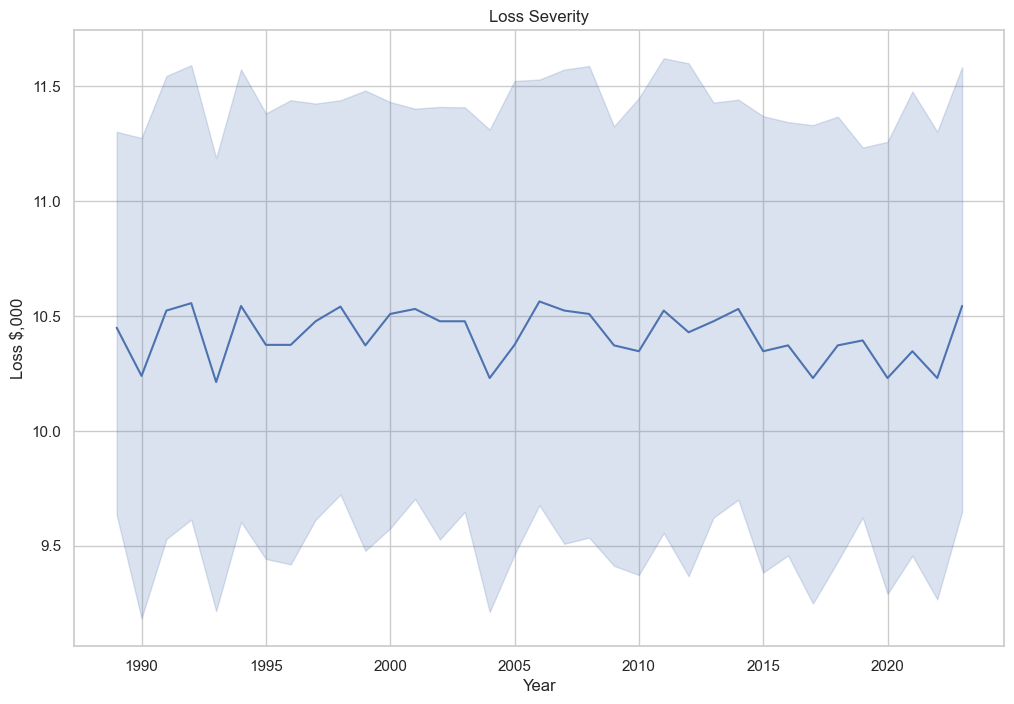

In [62]:
# Load data
path_op = Path("AT3OpRiskData.csv")
op = pd.read_csv(path_op)
op.drop(columns=['Unnamed: 0'], inplace=True)
display(op.head())

# Constants
RANDOM_STATE = 123456
CONFIDENCE_LEVEL = 0.99

# Initialise operational risk measurement class
op_risk = OperationalRiskMeasurement(data=op, confidence_level=CONFIDENCE_LEVEL, random_state=RANDOM_STATE)
op_risk.plot_loss_severity()


## Task 2.1
- It is known that the maximum likelihood estimator for the Poisson parameter $\mu$ is the sample mean of the number of losses per year. 
- Calculate this parameter estimate given the data.

In [63]:
mu_N_hat = op_risk.estimate_mu_frequency()

### Maximum likelihood estimator for the Poisson parameter $\mu$ = 51.4857 

## Task 2.2
- Using all observed loss amounts, assuming they are independent and identically distributed observations
- Fit a gamma distribution for the loss severity using `scipy.stats.gamma.fit()`. 
- Set `floc = 0` and `fscale = 1` so that you only obtain an estimate for the parameter $a$ of the gamma distribution.

In [64]:
a_hat, a_loc_hat, a_scale_hat = op_risk.fit_severity_distribution()

### Parameter $\hat{a} = 10.3634$ 

## Task 2.3
- Using 10,000 simulations (with random state = 12345)
- Use Monte Carlo simulation to generate scenarios for the aggregate loss random variable. 
- Calculate the $99$% $VaR$ and $ES$ using the empirical cdf.

#### Monte Carlo Simulation

**Method**
- Using 10,000 simulations, Let $k = 1, 2, \ldots , 10,000$
    1. Simulate $N(k)$ from Poisson distribution where $\mu$ is the sample mean of the number of losses per year.
        - *the simulated loss frequency*
    2. Simulate $X(k)$ from the Gamma distribution where $a$ is the estimated from the fitted Gamma distribution using the empirical loss severities
        - *the simulated loss severity*
    3. Calculate the sum $S^{(k)}_{N} = \sum^{N^{(k)}}_{n=1} X^{(k)}_{n}$
        - *the simulated aggregate loss for $k$*
    4. Use the set of simulated aggregate losses $\set{S^{(k)}_{N}}_{k=1,\ldots,10,000}$ to calculate the empirical $VaR_{0.99}$ and $ES_{0.99}$


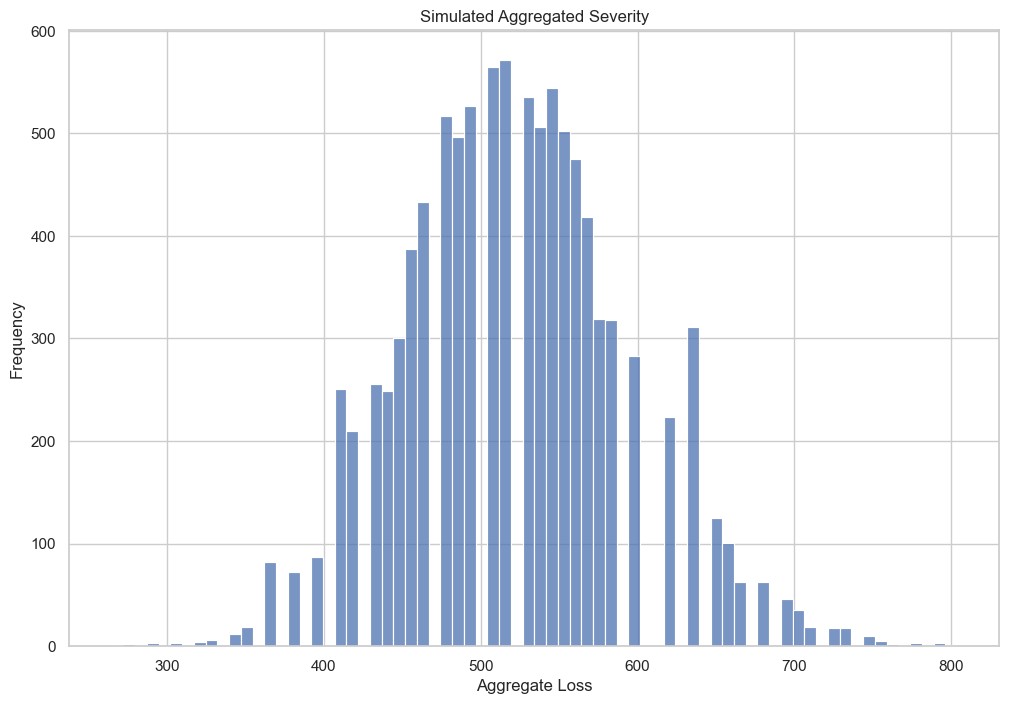

### $VaR_{0.99}$ & $ES_{0.99}$ (empirical)

#### &emsp; - VaR: 701.9457<br /> &emsp; - ES: 727.2220

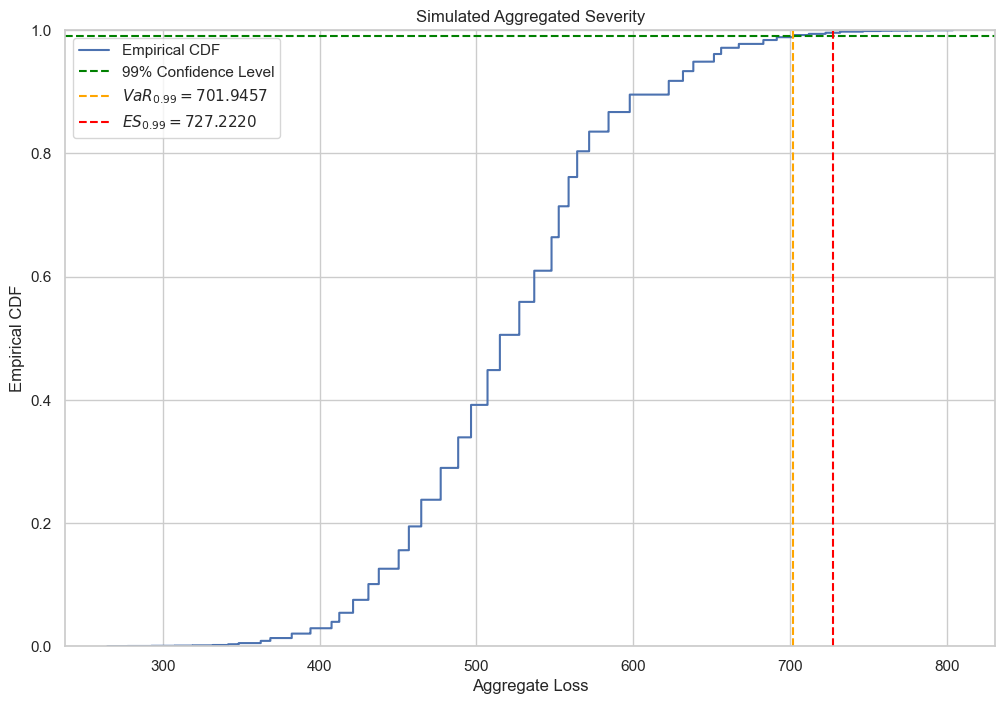

In [18]:
# N_SIMULATIONS = 1_000_000
N_SIMULATIONS = 10_000

mc_risk_measurement = op_risk.simulate_aggregated_severity_mc(N_simulations=N_SIMULATIONS)

## Task 2.4
- Using a grid with $2^{16}$ points and a grid spacing of $\delta = 0.05$
- Discretize the severity distribution using an upper discretization scheme. 
- Using the Fourier transform approach, calculate the $99$% $VaR$ and $ES$ of the aggregate loss distribution.

#### Fourier Transform Simulation

**Method**
- Given: 
    - $M=2^{16}$
    - Since $p_{N}(n) = \dfrac{e^{-\lambda} \lambda^{n}}{n!}$ for any $n \geq 0$, then for any $s>0$
    - The $pgf$ of $N$ is
    $$
    \Pi_N(s) := \sum_{n=0}^{\infty} p_N(n) s^n = e^{-\lambda (1 - s)}.
    $$

    - If $G$ is the loss severity $df$, then

    $$
    \hat{F}_{S_{N}} = e^{-\lambda(1 - \hat{G}(s))}, \  s \geq 0
    $$

    - In this case, $S_{N}$ is known as a compound Poisson random variable and write $S_{N} \sim CPoi(\lambda,G)$.
    
1. Discretise the severity distribution
    - Construct a grid $X = \{0, \delta, 2\delta, \ldots, (M-1)\delta\}$.  
    - Approximate the severity pmf by differencing the severity CDF.

2. Apply the FFT to the severity pmf
    - Compute $\widehat{g} = \mathrm{FFT}(g_x)$, the discrete Fourier transform.

3. **Apply the compound Poisson transform**  
   - Use the pgf of the Poisson distribution:  
     $$
     \Pi_N(s) = e^{-\lambda(1 - s)}.
     $$  
   - Compute the Fourier transform of aggregate losses:  
     $$
     \widehat{f}_x = \Pi_N(\widehat{g}_x).
     $$

4. Inverse FFT to obtain the aggregate loss pmf
   - Apply $\mathrm{IFFT}(\widehat{f})$ to get the discretised probability mass function of $S_N$.  
   - Compute the corresponding CDF by cumulative summation.

5. Compute VaR and ES
   - $VaR_{\alpha}$: first grid value where $CDF \geq \alpha$.  
   - $ES_{\alpha}$: conditional expectation over all grid points $ \geq VaR$.

  <!-- In the FFT step this is applied to the Fourier transform of the severity pmf via
  $$
  \widehat f = \Pi_N(\widehat g) = \exp\{\lambda(\widehat g - 1)\},
  $$ -->

<!-- Given M = 2L for some integer L, the severity cdf G, and the pgf ΠN of the
frequency distribution:
1. Discretize G to obtain a sequence {gx}x∈X of length M using one of
the methods stated above.
2. Apply the FFT to the sequence {gx}x∈X, obtaining a vector of values of
length M corresponding to the Fourier transform of the severity pdf.
3. Calculateˆ
fx = ΠN(ˆ gx) for x∈X. The result is the discrete Fourier
transform of the aggregate loss r.v. SN
4. Implement the inverse FFT to {fx}x∈X. This is a discretization of the
aggregate loss distribution with the same discretization grid X. 

A discretized version of the aggregate loss cdf is given by the sequence
{Fx}x∈X, where
Fx :=
fy, x∈X.
y∈X
y≤x
• VaRc(SN) can be approximated as
VaRc(SN) = min{x∈X: Fx ≥c}, c∈(0,1).
• Using the representation ESc(SN) = 1
1−c
∞
VaRc (SN ) xfSN (x) dx, we
obtain the approximation
ESc(SN) = 1
1−c
xfx.
x∈X
x≥VaRc (SN )

-->

#### Fourier transform $VaR_{0.99}$: 721.9000

#### Fourier transform $ES_{0.99}$: 751.7724

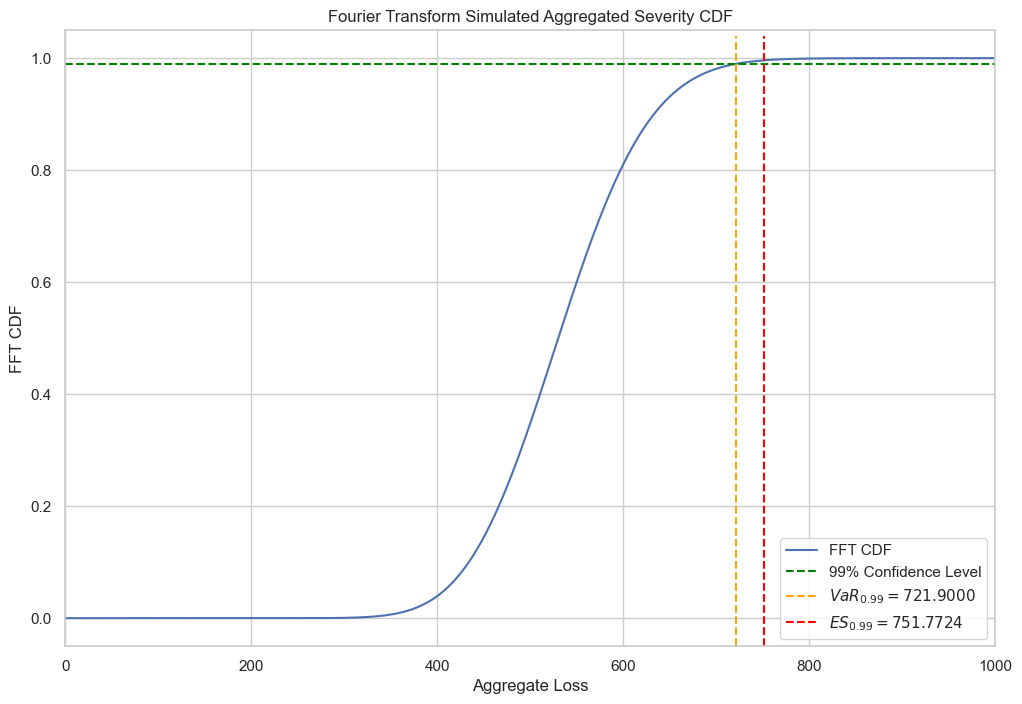

In [19]:
# Fast Fourier Transform parameters
N_FOURIER_TRANSFORM = 2**16
DELTA_FOURIER_TRANSFORM = 0.05

fft_risk_measurement = op_risk.simulate_aggregated_severity_fft(N_fourier_transform=N_FOURIER_TRANSFORM, delta_fourier_transform=DELTA_FOURIER_TRANSFORM)

## Task 2.5
- Use a translated gamma approximation of the aggregate loss distribution to approximate the $99$% $VaR$ and $ES$ of the aggregate loss distribution.

#### Translated Gamma Approximation

**Method**

- Approximate aggregate loss $S_N$ by the random variable $\kappa + Y$, where $\kappa \in R$ is a deterministic translation parameter and $Y \sim Gamma(\alpha,\beta)$.

- The parameters $\kappa$, $\alpha$, $\beta$ are estimated by matching the mean, variance, and skewness

- Given $S_N \sim CPoi(\lambda, G)$, then these equations become:

$$
\kappa + \dfrac{\alpha}{\beta} = \lambda \mathbb{E}[X_{1}], \, \dfrac{\alpha}{\beta^{2}} = \lambda \mathbb{E}[X_{1}^2], \, \dfrac{2}{\sqrt{\alpha}} = \dfrac{\mathbb{E}[X^{3}_{1}]}{\sqrt{\lambda (\mathbb{E}[X_{1}^2])^3}}
$$

so,
$$
\alpha = \left( \dfrac{2 (\sqrt{\lambda (\mathbb{E}[X_{1}^2])^3})}{\mathbb{E}[X^{3}_{1}]} \right)^2
$$

$$
\beta = \sqrt{\dfrac{\alpha}{\lambda \mathbb{E}[X_{1}^2]}}
$$

$$
\kappa = \lambda \mathbb{E}[X_1] - \dfrac{\alpha}{\beta}
$$

- Calculate $VaR_{c}$
$$
VaRc(S_N) \approx \kappa + F^{−1}_{Gamma(\alpha,\beta)}(c)
$$

- Calculate $ES_{c}$
$$
ES_{c}(S_N) \approx \kappa + \dfrac{\alpha / \beta}{1 - c} \left( 1 - F_{ Gamma(\alpha + 1, \beta) } ( F^{-1}_{ Gamma(\alpha, \beta)} (c)  \right)

$$

<!-- 1−c
1−FGamma(α+1,β) F−1
Gamma(α,β)(c) -->

#### Translated gamma $VaR_{0.99}$: 730.1297

#### Translated gamma $ES_{0.99}$: 760.8480

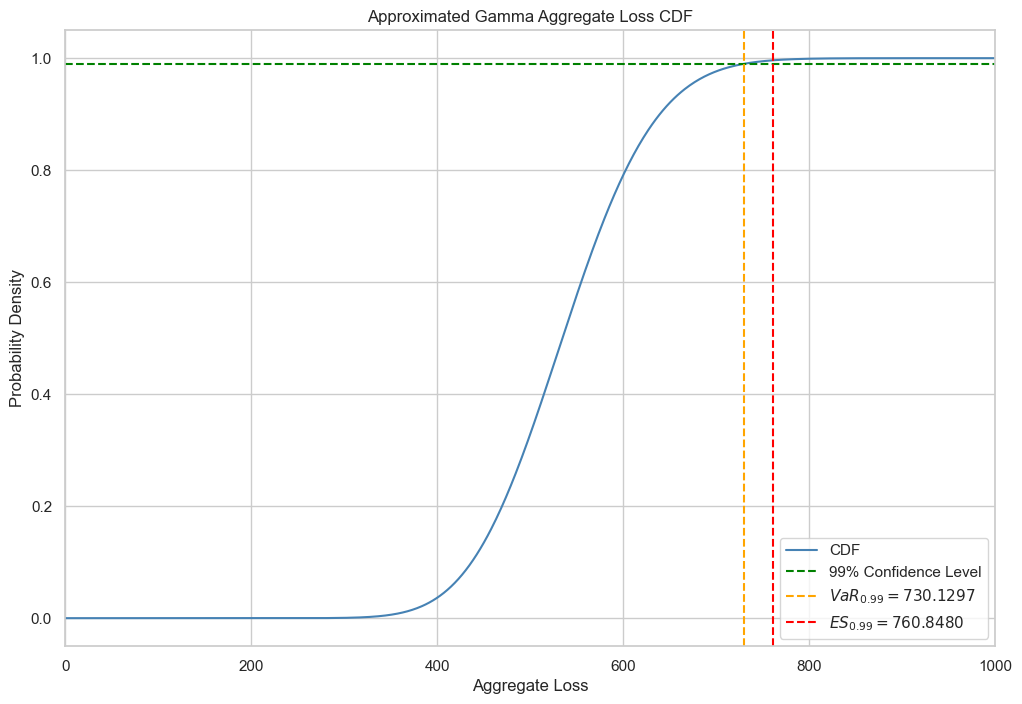

In [20]:
tg_risk_measurement = op_risk.simulate_aggregated_severity_tg(confidence_level=CONFIDENCE_LEVEL)

## Task 2.6
- Compare and contrast the risk measures you obtained using the different approaches.
- Do the different methods more or less agree with each other?

In [21]:
op_risk.compare_risk_measures()

,Method,VaR_99.0,ES_99.0,VaR_diff_%,ES_diff_%
0,Monte Carlo,701.9457,727.2220,0.00,0.00
1,Fast Fourier Transform,721.9000,751.7724,2.84,3.38
2,Translated Gamma,730.1297,760.8480,4.02,4.62


1. Relative differences (vs Monte Carlo)
	- FFT: $VaR$ +2.8%, $ES$ +3.4%
	- Translated Gamma: $VaR$ +4%, $ES$ +4.6%
	- Ordering holds as expected: for each method, $ES > VaR$.

2. What this says about each method
	- Monte Carlo (MC)
		- Likely slight underestimation of extreme tail due to sampling error at 99%
		- At the 0.99 quantile there may not be enough data in the tail to accurately approximate $VaR$ and $ES$ leading to a downward-biased.
	- FFT (Fast Fourier Transform)
		- Generally the closest to the model-implied truth for a compound Poisson–Gamma loss distribution approach (LDA), provided discretization (grid size, spacing, truncation) is set well. 
		- FFT > MC by ~3% which is consistent with MC sampling variance. 
		- Good balance of speed + accuracy.
	- Translated Gamma (TGA)
		- A moment-matched analytic approximation (matches mean/var/skew). 
		- It usually overshoots slightly in the right tail for heavy-tailed/semi-heavy severities, so being most conservative here (+4% vs MC) is normal. 
		- Great for speed and sanity checks, but it’s still an approximation.

**Summary**
- FFT yields higher VaR/ES than Monte Carlo by ~3%, consistent with finite-sample MC underestimation at high quantiles. 
- Translated Gamma is highest (~4% above MC), reflecting conservative tail from moment matching. 
- Across methods at 99%, FFT and TGA produce higher VaR/ES than Monte Carlo by ~3–4%. 
- This is consistent with finite-sample underestimation in MC tails and with TGA’s known conservative bias from moment matching. 
- Given the compound Poisson–Gamma LDA, FFT provides the most accurate numerical inversion 


### Discussion: Advanced Measurement Approach (AMA)

Under Basel II/III, the **Advanced Measurement Approach (AMA)** allows banks to
use internal models to estimate operational risk capital:

$$
S_N = \sum_{i=1}^{N} X_i,
\quad N \sim \text{Poisson}(\mu), \quad X_i \sim Gamma(a).
$$

The risk measure (e.g. 99.9% VaR) is then computed using one of several methods.

---

#### Advantages
- Risk-sensitive and data-driven.
- Reflects a bank’s own loss experience.
- Encourages improved risk management and governance.
- Integrates scenario and external data.

#### Disadvantages
- Data scarcity and model uncertainty.
- Computationally intensive (especially Monte Carlo).
- Sensitive to parameter estimation.
- Complex regulatory requirements and validation.

---

### AMA Computational Methods

| Method | Type | Advantages | Disadvantages |
|---------|------|-------------|----------------|
| **Monte Carlo Simulation** | Empirical | Flexible, intuitive | Slow for high quantiles, sampling error |
| **Fourier Transform (FFT)** | Numerical | Fast and precise | Sensitive to discretisation errors |
| **Gaussian Approximation** | Analytical | Simple, closed form | Inaccurate for heavy tails |
| **Translated Gamma Approximation** | Analytical | Captures skewness, better fit | Still approximate, parameter estimation needed |

---

**Summary:**  
The AMA provides a sophisticated and risk-sensitive framework for operational risk modeling,
but it comes with high data, modeling, and computational requirements.
Monte Carlo and FFT are more accurate but slower,
while Gaussian and Translated Gamma provide faster analytical approximations.

## 3. Question 3 — Alternative Risk Measure $\psi_{a,b}(L)$
Let $L$ be an integrable loss rv. For $a,b\in[0,1]$ with $a+b\le 1$,

$$\psi_{a,b}(L) := \frac{1}{b}\int_a^{a+b} \text{VaR}_{1-u}(L)\,du.$$

**Tasks:**
1) Prove the ES relation.
2) Express $\psi_{a,b}$ as linear combo of ES terms (find coefficients).
3) For $F_L(x)=1-(1+x)^{-2}$ (Pareto(2), $x\ge0$), compute VaR/ES at 0.95 and 0.975.
4) Compute $\psi_{0.05,0.025}(L)$.
5) Sweep $a$ and $b$ over powers of $10$ and compute $\psi_{a,b}(L)$.
6) Plot and infer limits as $b\to 0^+$ (fixed $a$) and as $a\to 0^+$ (fixed $b$).

## Task 3.1

- Prove that
$$
\psi_{a,b} = \dfrac{a+b}{b} ES_{1-(a+b)}(L) - \dfrac{a}{b} ES_{1-a}(L)
$$


##### Change of Variables for Expected Shortfall

Starting from the standard definition:
$$
\text{ES}_\alpha(L)
= \frac{1}{1 - \alpha} \int_\alpha^1 \text{VaR}_u(L)\,du,
$$

Let $x = 1 - \alpha$

So, $\alpha = 1 - x$

Substitute $u = 1 - t$ so that: 

$$
\dfrac{du}{dt}(1 - t) = -1 \Rightarrow du = -dt
$$

When $u=\alpha \Rightarrow \quad t = 1 - \alpha = x$

When $u=1 \Rightarrow \quad t = 1-1 = 0$

$$
\int_\alpha^1 \text{VaR}_u(L)\,du
= \int_{t=x}^{t=0} \text{VaR}_{1-t}(L)\,(-dt)
= \int_0^x \text{VaR}_{1-t}(L)\,dt.
$$

Hence,
$$
\boxed{
\text{ES}_{1-x}(L) = \frac{1}{x} \int_0^x \text{VaR}_{1-u}(L)\,du
}
$$

This expresses Expected Shortfall in terms of **tail probability $x$** rather than the quantile level $\alpha = 1-x$.

Therefore
$$
x \text{ES}_{1-x}(L) = \int_0^x \text{VaR}_{1-u}(L)\,du
$$

##### Compute the integral over $[a, a+b]$

Starting from

$$
x \text{ES}_{1-x}(L) = \int_0^x \text{VaR}_{1-u}(L)\,du \\
$$
$$
\begin{aligned}
\int^{a+b}_{0} VaR_{1-u} du &= (a+b) VaR_{1-(a+b)}(L) \\
\int^{a}_{0} VaR_{1-u} du &= a VaR_{1-a}(L)
\end{aligned}
$$

By the difference rule of integration

$$
\int^{a+b}_{a} VaR_{1-u}(L)\,du = (a+b)VaR_{1-(a+b)}(L) - a VaR_{1-a}(L)
$$

Recognise that
$$
\int_0^x \text{VaR}_{1-u}(L)\,du = x \text{ES}_{1-x}(L)
$$

So

$$
(a+b)VaR_{1-(a+b)}(L) - a VaR_{1-a}(L) = (a+b) ES_{1-(a+b)}(L) - a ES_{1-a}(L)
$$

Given
$$
\psi_{a,b}(L) := \frac{1}{b}\int_a^{a+b} \text{VaR}_{1-u}(L)\,du
$$

Therefore
$$
\boxed{
\psi_{a,b}(L) = \dfrac{a+b}{b} ES_{1-(a+b)}(L) - \dfrac{a}{b} ES_{1-a}(L)
}
$$

As required  $\Box$


## Task 3.2

- Let $\alpha = 1−a$ and $\beta = 1−b$. 
- Show that $\psi_{a,b}(L)$ can be written as a linear combination of $ES_{\alpha+\beta−1}(L)$ and $ES_{\alpha}(L)$
- That is, find constants $k_1$ and $k_2$ (in terms of $\alpha$ and $\beta$) such that
$$
\psi_{\alpha, \beta} = k_1 ES_{\alpha + \beta - 1}(L) + k_2 ES_{\alpha}(L)
$$


From Task 3.1
$$
\psi_{a,b}(L) = \dfrac{a+b}{b} ES_{1-(a+b)}(L) - \dfrac{a}{b} ES_{1-a}(L)
$$
where $a,b \in [0,1]$ and $a+b \leq 1$

Let 
$$
\begin{align*}
\alpha &:= 1-a, \\ \beta &:= 1-b
\end{align*}
$$

Then 
$$
% \begin{align}
\begin{align*}
a &= 1-\alpha, \\ b &= 1-\beta
% \end{align}
\end{align*}
$$

So,
$$
\begin{align*}
1 - (a+b) &= 1 - (1-\alpha + 1-\beta) \\ 
&= 1 - (2 - \alpha - \beta) \\
&= \alpha + \beta - 1
\end{align*}
$$
and
$$
\begin{align*}
\dfrac{a+b}{a} &= \dfrac{1-\alpha + 1-\beta}{1-\beta} \\
&= \dfrac{2-\alpha-\beta}{1-\beta}
\end{align*}
$$
and
$$
\begin{align*}
\dfrac{a}{b} = \dfrac{1-\alpha}{1-\beta}
\end{align*}
$$

Hence
$$
\psi_{a,b}(L) = \dfrac{2-\alpha-\beta}{1-\beta} ES_{\alpha + \beta - 1}(L) - \dfrac{1-\alpha}{1-\beta} ES_{1-\alpha}(L)
$$

Therefore
$$
\boxed{
k_1 = \dfrac{2-\alpha-\beta}{1-\beta}, \, k_2 = \dfrac{1-\alpha}{1-\beta}
}
$$

## Task 3.3 
- Calculate $VaR_{\alpha}(L)$ and $ES_{\alpha}(L)$, for $\alpha \in$ {$0.95,0.975$}.

**Assuming that $L$ has $cdf$ $F_L(x) = 1−(1 + x)^{−2}$, for $x \geq 0$ (given in the question).**


#### Derive Value-at-Risk ($VaR$)
$$
\begin{align*}
VaR_\alpha(L) &= F_{L}^{-1}(x) \\
\alpha &= 1 - (1+x)^{-2} \\
\alpha - 1 &= - (1+x)^{-2} \\
1 - \alpha &= (1+x)^{-2} \\
(1 - \alpha)^{-\frac{1}{2}} &= 1+x \\
x &= (1 - \alpha)^{-\frac{1}{2}} - 1
\end{align*}
$$
Hence
$$
\boxed{ VaR_{\alpha}(L) = (1 - \alpha)^{-\frac{1}{2}} - 1 }
$$

#### Derive Expected Shortfall ($ES$)
$$
\begin{align*}
ES_{\alpha} &= \dfrac{1}{1-\alpha} \int^{1}_{\alpha} VaR_{u}\,du \\
&= \dfrac{1}{1-\alpha} \int^{1}_{\alpha} \left((1-u)^{-\frac{1}{2}} \,du  -  1 \right)\,du 
\end{align*}
$$

Let
$$
\begin{align*}
v &= 1-\alpha \\ \dfrac{dv}{du}(1-u) &= -1 \Rightarrow dv = -du
\end{align*}
$$

Substitute boundaries, when
$$
\begin{align*}
u=\alpha &\Rightarrow v=1-\alpha \\
u=1 &\Rightarrow v=0
\end{align*}
$$

Ingrate by substitution
$$
\begin{align*}
ES_{\alpha}(L) &= \dfrac{1}{1-\alpha} \left[ \int^{0}_{1-\alpha} v^{-\frac{1}{2}}\,-dv - \int^{0}_{1-\alpha} 1 \,-dv \right] \\
&= \dfrac{1}{1-\alpha} \left[ \int^{1-\alpha}_{0} v^{-\frac{1}{2}}\,dv - \int^{1-\alpha}_{0} 1 \,dv \right] \\
&= \dfrac{1}{1-\alpha} \left[  \left. \dfrac{v^{1-\frac{1}{2}}}{1-\frac{1}{2}} \right|_{0}^{1-\alpha} \left. - \, v \right|_{0}^{1-\alpha}  \right] \\
&= \dfrac{1}{1-\alpha} \left[ 2(1-\alpha)^{\frac{1}{2}} - (1-\alpha) \right] \\
&= \dfrac{2(1-\alpha)^{\frac{1}{2}}}{1-\alpha} - \dfrac{1-\alpha}{1-\alpha} \\
&= 2(1-\alpha)^{-\frac{1}{2}} - 1
\end{align*}
$$

$$
\boxed{
ES_{\alpha}(L) = 2(1-\alpha)^{-\frac{1}{2}} - 1
}
$$

In [31]:
def VaR_alpha(alpha):
    return (1 - alpha)**(-1/2) - 1

def ES_alpha(alpha):
    return 2*(1-alpha)**(-1/2) - 1

alphas = set[float]([0.95, 0.975])
for alpha in alphas:    
    display(Markdown(f"#### $VaR_{{ {alpha} }}(L) = {VaR_alpha(alpha):.4f}$"))
    display(Markdown(f"#### $ES_{{ {alpha} }}(L) = {ES_alpha(alpha):.4f}$"))

#### $VaR_{ 0.95 }(L) = 3.4721$

#### $ES_{ 0.95 }(L) = 7.9443$

#### $VaR_{ 0.975 }(L) = 5.3246$

#### $ES_{ 0.975 }(L) = 11.6491$

## Task 3.4 
- Calculate $\psi_{0.05,0.025}(L)$.

From Task 3.1
$$
\psi_{a,b}(L) = \dfrac{a+b}{b} ES_{1-(a+b)}(L) - \dfrac{a}{b} ES_{1-a}(L)
$$

From Task 3.3
$$
ES_{\alpha}(L) = 2(1-\alpha)^{-\frac{1}{2}} - 1
$$

Let
$$
a = 0.05, \, b = 0.025
$$

$$
\psi_{a,b}(L) = \frac{0.05 + 0.025}{0.025} 2(1 - (0.05 + 0.25)^{-\frac{1}{2}} - 1) - (\frac{0.05}{0.025} 2(1 - 0.05)^{-\frac{1}{2}} - 1) \approx 3.0204
$$


In [ ]:
def psi_ab(a, b):
    return (a + b) / b * ES_alpha(1 - (a + b)) - a / b * ES_alpha(1 - a)

display(Markdown(f"### $\psi_{{0.05,0.025}}(L) = {psi_ab(0.05, 0.025):.4f}$"))


### $\psi_{0.05,0.025}(L) = 3.0204$

## Task 3.5
- For $a \in$ {$10^{−1},10^{−2},...,10^{−9}$}, calculate $\psi_{a,b}(L)$ 
    - where $b = 0.025$ is fixed. 
- Similarly, for $b \in$ {$10^{−1},10^{−2},...,10^{−9}$}, calculate $\psi_{a,b}(L)$ 
    - where $a = 0.05$ is fixed.

In [ ]:
def F_L(x):
    if x < 0:
        return 0
    else:
        return 1 - (1 + x)**(-2)

def plot_psi(a, b, color='blue'):
    # Generate x values: from -1 to 10 to show behavior around 0 and positive side
    psi = psi_ab(a, b)
    # Compute the y-intersection point
    y_intersect = F_L(psi)
    
    VaR = VaR_alpha(y_intersect)
    ES = ES_alpha(y_intersect)

    # Create the plot
    x_values = np.linspace(-1, max(psi+1, 10), 500)
    y_values = np.array([F_L(x) for x in x_values])
    plt.figure(figsize=(8, 6))
    sns.lineplot(x=x_values, y=y_values, label='$F_L(x)$', color=color)
    
    # Horizontal line at the intersection (y = F_L(psi))
    plt.axhline(y=y_intersect, color='green', linestyle='--', label=f'Intersection at y={y_intersect:.4f}')
    plt.axvline(x=VaR, color='green', linestyle='--', label=f'$VaR_{{ {y_intersect:.4f} }}(L)={VaR:.4f}$')
    plt.axvline(x=ES, color='green', linestyle='--', label=f'$ES_{{ {y_intersect:.4f} }}(L)={ES:.4f}$')
    plt.axvline(x=psi, color='red', linestyle='--', label=f'$\psi_{{ {a}, {b} }}(L)={psi:.4f}$')
    plt.title('Plot of the Function $F_L(x)$')
    plt.xlabel('x')
    plt.ylabel('$F_L(x)$')
    plt.axvline(x=0, color='gray', linestyle='--', label='x=0')
    plt.legend()
    plt.grid(True)
    plt.show()



In [30]:
# 3.5.a
b = 0.025
fixed_b = list[float]()
display(Markdown(f"### Fixed $b = {b}$"))
for i in range(1, 10):
    a = 10**-i
    psi = psi_ab(a, 0.025)
    fixed_b.append(psi)
    # plot_psi(a, b, 'blue')
    display(Markdown(f"#### $\psi_{{ {a}, {b} }}(L) = {psi:.4f}$"))

print('-'*80)

# 3.5.b
a = 0.05
fixed_a = list[float]()
display(Markdown(f"### Fixed $a = {a}$"))
for i in range(1, 10):
    b = 10**-i
    psi = psi_ab(0.05, b)
    fixed_a.append(psi)
    # plot_psi(a, b, 'orange')
    display(Markdown(f"#### $\psi_{{ {a}, {b} }}(L) = {psi:.4f}$"))


### Fixed $b = 0.025$

#### $\psi_{ 0.1, 0.025 }(L) = 1.9860$

#### $\psi_{ 0.01, 0.025 }(L) = 5.9666$

#### $\psi_{ 0.001, 0.025 }(L) = 9.3698$

#### $\psi_{ 0.0001, 0.025 }(L) = 10.8744$

...

#### $\psi_{ 0.05, 1e-05 }(L) = 3.4719$

#### $\psi_{ 0.05, 1e-06 }(L) = 3.4721$

#### $\psi_{ 0.05, 1e-07 }(L) = 3.4721$

#### $\psi_{ 0.05, 1e-08 }(L) = 3.4721$

#### $\psi_{ 0.05, 1e-09 }(L) = 3.4721$

## Task 3.6

- Plot your results in the previous item on the same plot window and infer what happens to $\psi_{a,b}(L)$ as $b \rightarrow 0^+$ (with a fixed) 
- and as $a \rightarrow 0^+$ (with b fixed).

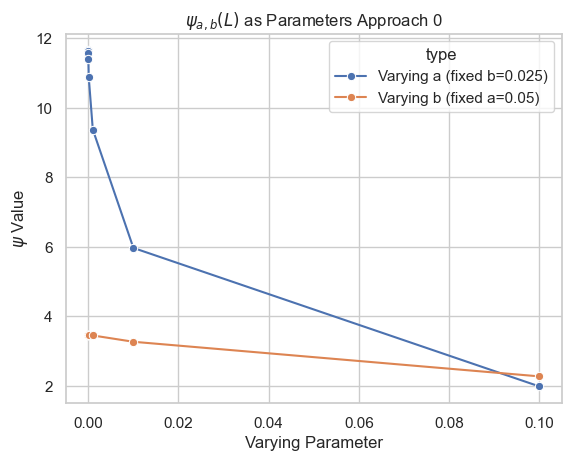

In [ ]:
param_values = [10**-i for i in range(1, 10)]

# Data for varying a (fixed b=0.025)
df_varying_a = pd.DataFrame({
    'param': param_values,
    'psi': fixed_b,
    'type': 'Varying a (fixed b=0.025)'
})

# Data for varying b (fixed a=0.05)
df_varying_b = pd.DataFrame({
    'param': param_values,
    'psi': fixed_a,
    'type': 'Varying b (fixed a=0.05)'
})

# Combine into one DataFrame
df = pd.concat([df_varying_a, df_varying_b])

# Plot with seaborn
sns.lineplot(data=df, x='param', y='psi', hue='type', marker='o')
plt.title('$\psi_{a,b}(L)$ as Parameters Approach 0')
plt.xlabel(f'Varying Parameter')
plt.ylabel('$\psi$ Value')
plt.grid(True)
plt.show()

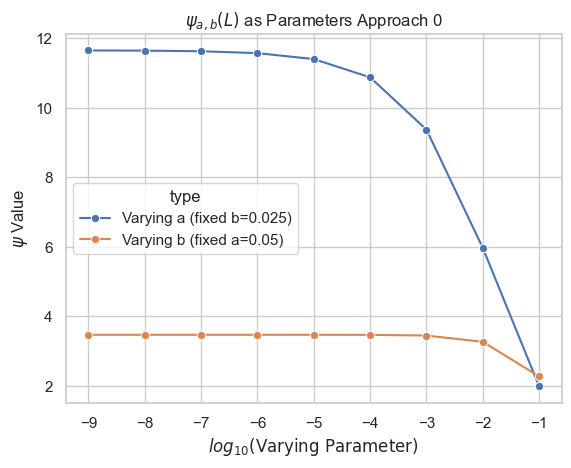

In [ ]:
param_values = [10**-i for i in range(1, 10)]

# Data for varying a (fixed b=0.025)
df_varying_a = pd.DataFrame({
    'log_param': np.log10(param_values),
    'psi': fixed_b,
    'type': 'Varying a (fixed b=0.025)'
})

# Data for varying b (fixed a=0.05)
df_varying_b = pd.DataFrame({
    'log_param': np.log10(param_values),
    'psi': fixed_a,
    'type': 'Varying b (fixed a=0.05)'
})

# Combine into one DataFrame
df = pd.concat([df_varying_a, df_varying_b])

# Plot with seaborn
sns.lineplot(data=df, x='log_param', y='psi', hue='type', marker='o')
plt.title('$\psi_{a,b}(L)$ as Parameters Approach 0')
plt.xlabel(f'$log_{{10}}(\\text{{Varying Parameter}})$')
plt.ylabel('$\psi$ Value')
plt.grid(True)
plt.show()

#### **Behaviour as $ b \to 0^+ $ (with $a$ fixed)**  
This corresponds to the *orange* curve.

- For very small $a$ the curve is essentially flat:  
  $ \psi_{a,b}(L) $ stays close to a constant value (around 11–12).
- As $a$ increases (moving right, up to $a \approx 0.1$), $ \psi_{a,b}(L) $ decreases sharply.

**Conclusion:**  
As $a \to 0^+$ with $b$ fixed, $ \psi_{a,b}(L) $ converges to a **finite limit** (a horizontal plateau in the plot).  
$$
\lim_{a \to 0^+} \psi_{a,b}(L) = \mathrm{ES}_{1-b}(L),
$$
so the risk measure tends to the Expected Shortfall at level $1-b$.

---

#### **Behaviour as $ a \to 0^+ $ (with $b$ fixed)**  
This corresponds to the *blue* curve.

- For very small $b$ $ \psi_{a,b}(L) $ is again almost flat, around 3.4–3.5.
- As $b$ increases toward 0.1 (moving right), the value of $ \psi_{a,b}(L) $ gradually decreases.

**Conclusion:**  
As $b \to 0^+$ with $a$ fixed, $ \psi_{a,b}(L) $ also converges to a **finite limit**.  
Using the integral representation,
$$
\psi_{a,b}(L) = \frac{1}{b}\int_a^{a+b} \text{VaR}_{1-u}(L)\,du,
$$
the limit is
$$
\lim_{b \to 0^+} \psi_{a,b}(L) = \text{VaR}_{1-a}(L),
$$
i.e. the risk measure tends to the Value-at-Risk at level $1-a$.


### Properties of Risk Measures

Let $\rho(L)$ be a risk measure applied to a random loss variable $L$.

| Property | Mathematical Definition | Intuitive Meaning |
|-----------|--------------------------|-------------------|
| **Monotonicity** | $L_1 \le L_2 \implies \rho(L_1) \le \rho(L_2)$ | If one portfolio always incurs smaller losses, it should be less risky. |
| **Translation Invariance** | $\rho(L + c) = \rho(L) + c$ | Adding a certain (risk-free) loss $c$ increases risk by exactly $c$. |
| **Positive Homogeneity** | $\rho(\lambda L) = \lambda \rho(L)$ for $\lambda > 0$ | Scaling the portfolio by $\lambda$ scales the risk by the same factor. |
| **Subadditivity** | $\rho(L_1 + L_2) \le \rho(L_1) + \rho(L_2)$ | The total risk of combined portfolios is not greater than the sum of individual risks (diversification principle). |

A **coherent** risk measure $\rho(L)$ satisfies:

1. **Monotonicity:** if $L_1 \le L_2$ then $\rho(L_1) \le \rho(L_2)$  
2. **Translation invariance:** $\rho(L + c) = \rho(L) + c$  
3. **Positive homogeneity:** $\rho(\lambda L) = \lambda\rho(L)$, $\lambda > 0$  
4. **Subadditivity:** $\rho(L_1 + L_2) \le \rho(L_1) + \rho(L_2)$


> I acknowledge the use of ChatGPT (OpenAI) to assist with explanations of quantitative finance concepts, clarification of theory, development of markdown for my notebook, and guidance on implementing methods such as the FFT, Euler capital allocation, RORAC optimisation, and the Poisson–Gamma LDA. The output was modified by editing wording, adjusting technical details, rewriting code, and integrating the explanations into my own analysis. I checked the accuracy of the information by verifying formulas against lecture notes, cross-checking mathematical results manually, and validating numerical outputs through my own code and calculations.

> **References**

> Artzner, P., Delbaen, F., Eber, J.-M. & Heath, D. 1999, *Coherent Measures of Risk*, Mathematical Finance, vol. 9, no. 3, pp. 203–228.

> Černý, A. (2009). *Mathematical Techniques in Finance: Tools for Incomplete Markets*. Princeton University Press, New Jersey, USA.

> Dutang, C., Goulet, V., and Pigeon, M. (2008). actuar: An R package for actuarial science. Journal of Statistical Software, 25(7):1–37.

> Gribkova, N. V., Su, J., and Zitikis, R. (2023). *Estimating the VaR-induced Euler allocation rule*. ASTIN Bulletin, 53:619–635.

> McNeil, A. J., Frey, R., & Embrechts, P. (2015). *Quantitative Risk Management: Concepts, Techniques, and Tools* (Rev. ed.). Princeton, NJ: Princeton University Press.  

> Rockafellar, R. T. and Wets, R. J.-B. (1998). *Variational Analysis*. Springer-Verlag, Berlin, Germany.